# Redes Neurais Convolucionais (CNN) — Classificação de Resíduos (Lixo)

**Disciplina:** Machine Learning e Otimização
**Tema:** Implementação de uma CNN, ajuste de hiperparâmetros com Optuna e arquitetura clássica da literatura.

## Integrantes da equipe

- FELIPE CLAUDINO CRUZ
- CARLOS EDUARDO
- GABRIEL MATTOS TEIXEIRA DOS SANTOS

---

## Declaração de Uso de IA Generativa

- **Ferramenta utilizada:** Claude Opus 4.8🔥
- **Finalidade do uso:** Plotagens gráficas e tratamento de erros.

# Imports, versões e reprodutibilidade

Nesta seção instalamos e importamos as bibliotecas, exibimos as versões e fixamos a *seed* aleatória.


In [36]:
# No Google Colab, descomente as linhas de instalação abaixo se necessário.
!pip install optuna -q
!pip install tensorflow -q
!pip install pandas -q
!pip install matplotlib -q
!pip install seaborn -q
!pip install scikit-learn -q



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
!python --version
!pip show tensorflow | head -n 2


Python 3.13.3


'head' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [38]:
import os
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import optuna

# Exibe as versões das bibliotecas para garantir compatibilidade
print(f"Versões usadas:\n"
      f"TensorFlow: {tf.__version__}\n"
      f"Keras: {keras.__version__}\n"
      f"NumPy: {np.__version__}\n"
      f"Pandas: {pd.__version__}\n"
      f"Matplotlib: {matplotlib.__version__}\n")
print(f"Versão do Optuna: {optuna.__version__}")

# --- Configuração de reprodutibilidade ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


Versões usadas:
TensorFlow: 2.21.0
Keras: 3.14.1
NumPy: 2.4.6
Pandas: 3.0.3
Matplotlib: 3.10.9

Versão do Optuna: 4.9.0


# 1. Escolha e Validação do Dataset

**Nome do dataset:** Garbage Classification (resíduos padronizados em 256×256) — pasta `standardized_256`.

**Descrição:** imagens de diferentes tipos de lixo/resíduos, organizadas em uma pasta por classe.

**Classes (9):** `battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes`.

**Total aproximado:** ~11.805 imagens (acima do mínimo de 1000, com mais de 100 imagens por classe).

**Ajuste:** Uma das classes foi removida por recomendação da professora, restando **9 classes**.


## Carregando o dataset no ambiente

In [39]:
# === Configuração do caminho do dataset ===

# --- Opção A: Google Drive (recomendado no Colab) ---
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/standardized_256'

# --- Opção B: upload de um .zip ---
# from google.colab import files
# files.upload()  # envie standardized_256.zip
# !unzip -q standardized_256.zip -d /content/
# DATA_DIR = '/content/standardized_256'

# --- Opção C: execução local ---
DATA_DIR = "standardized_256"

data_dir = pathlib.Path(DATA_DIR)
assert data_dir.exists(), f"Caminho não encontrado: {data_dir.resolve()}"

class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])
num_classes = len(class_names)

print("📁 Caminho do dataset:", data_dir.resolve())
print(f"\n🗑️ Classes encontradas ({num_classes}):")
print(class_names)


📁 Caminho do dataset: C:\Users\Felipe Cruz\Desktop\CESUPA\7° SEMESTRE\MACHINE LEARNING E OTIMIZACAO\26.05.09_RedesNeuraisConvolucionais\standardized_256

🗑️ Classes encontradas (9):
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes']


## Construção do dataframe de imagens

Percorremos cada pasta de classe e montamos um `DataFrame` com o caminho de cada imagem e o seu rótulo (texto e código numérico).


In [40]:
# --- Construção de um dataframe com caminhos das imagens e classes ---

image_paths = []
labels = []

extensoes = (".jpg", ".jpeg", ".png", ".bmp")

for class_name in class_names:
    class_dir = data_dir / class_name
    for image_path in class_dir.glob("*"):
        if image_path.suffix.lower() in extensoes:
            image_paths.append(str(image_path))
            labels.append(class_name)

df = pd.DataFrame({"image_path": image_paths, "label": labels})

# Mapeamento entre o nome da classe e um código numérico
label_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_label = {idx: class_name for class_name, idx in label_to_id.items()}
df["label_id"] = df["label"].map(label_to_id).astype("int32")

print("Total de imagens:", len(df))
print("\nMapeamento das classes:")
print(label_to_id)

print("\nAmostra do dataframe:")
display(df.head())


Total de imagens: 11805

Mapeamento das classes:
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8}

Amostra do dataframe:


,image_path,label,label_id
0,standardized_256\battery\battery_10.jpg,battery,0
1,standardized_256\battery\battery_100.jpg,battery,0
2,standardized_256\battery\battery_101.jpg,battery,0
3,standardized_256\battery\battery_102.jpg,battery,0
4,standardized_256\battery\battery_103.jpg,battery,0


Imagens por classe:


label
battery        755
biological     699
cardboard     1411
clothes       1892
glass         1736
metal          930
paper         1336
plastic       1597
shoes         1449
Name: count, dtype: int64

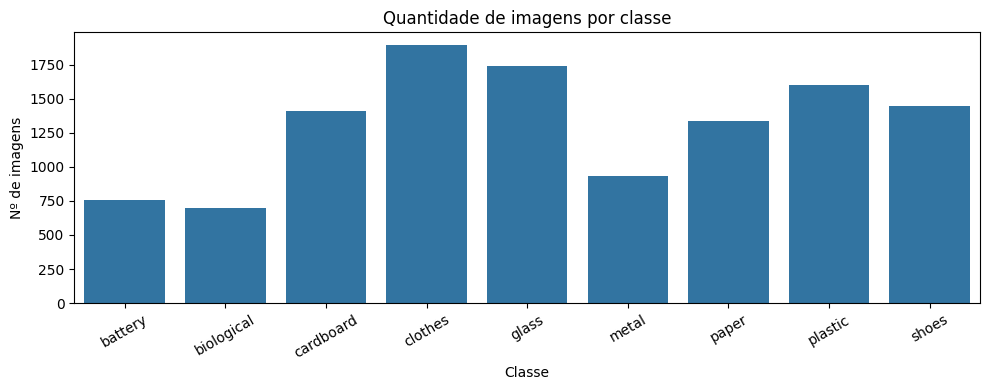

In [41]:
# --- Distribuição das classes (verificação de balanceamento) ---

contagem = df["label"].value_counts().sort_index()
print("Imagens por classe:")
display(contagem)

plt.figure(figsize=(10, 4))
sns.barplot(x=contagem.index, y=contagem.values)
plt.title("Quantidade de imagens por classe")
plt.ylabel("Nº de imagens")
plt.xlabel("Classe")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 📝 Análise — Validação e balanceamento do dataset
- Os citérios mínimos de 100 imagens por classe está sendo ebedecida.
- Quantidades mais frequêntes de imagens de roupas, pois esses itens repetindo muita vezes no treino pode fazer com que a ia interprete que, caso ela não saiba o que colocar, seria seguro chutar uma roupa. 

## Visualização de amostras

Exibimos algumas imagens originais com a classe e o tamanho em pixels.


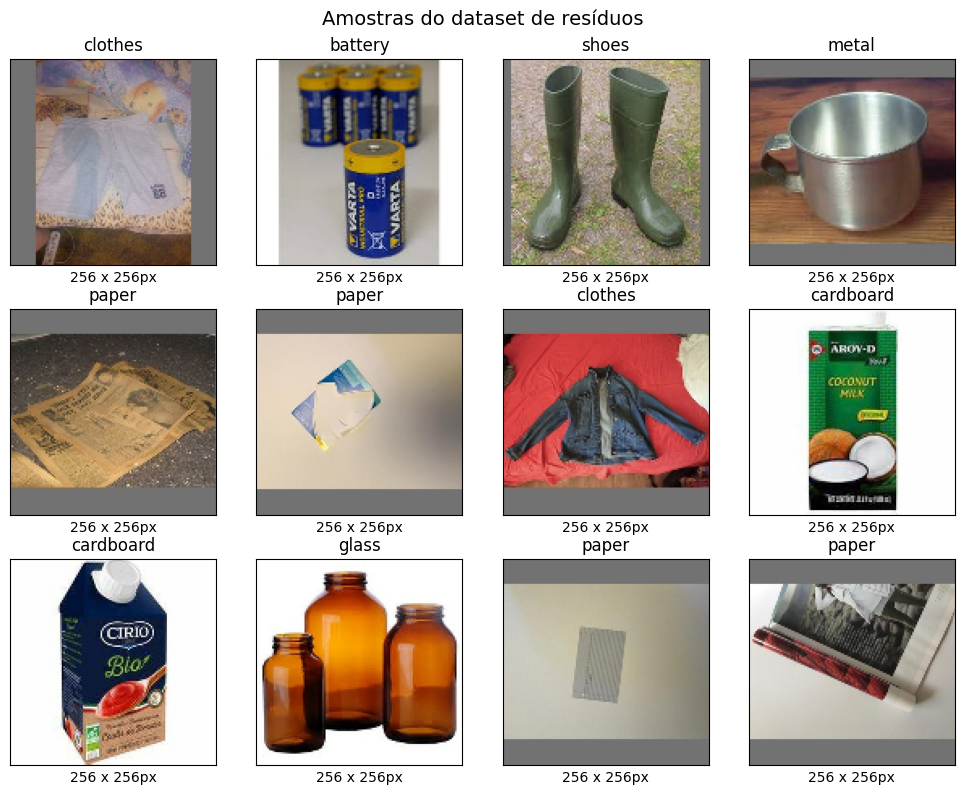

In [42]:
# --- Visualização de algumas imagens do dataset ---

plt.figure(figsize=(10, 8))
sample_df = df.sample(12, random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    img_original = tf.keras.utils.load_img(row["image_path"])
    largura, altura = img_original.size
    img = tf.keras.utils.load_img(row["image_path"], target_size=(128, 128))

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.xlabel(f"{largura} x {altura}px")
    plt.xticks([]); plt.yticks([])

plt.suptitle("Amostras do dataset de resíduos", fontsize=14)
plt.tight_layout()
plt.show()


# 2. Pré-processamento do Dataset

### Subamostragem estratificada (controle de custo computacional)

O dataset completo tem ~11 mil imagens. Para viabilizar o treino no Colab, reduzimos para **~6.000 imagens no total**, mantendo a **proporção das classes** (estratificação). O conjunto de teste é separado **desde o início** e usado **somente na avaliação final**.


In [43]:
# --- Subamostragem estratificada para ~6000 imagens ---
TAMANHO_TOTAL = 6000

frac = min(1.0, TAMANHO_TOTAL / len(df))

if frac < 1.0:
    df_amostra, _ = train_test_split(
        df,
        train_size=frac,
        stratify=df["label_id"],
        random_state=SEED
    )
    df_amostra = df_amostra.reset_index(drop=True)
else:
    df_amostra = df.copy()

print(f"Dataset original: {len(df)} imagens")
print(f"Dataset usado (subamostra): {len(df_amostra)} imagens")
print("\nDistribuição por classe na subamostra:")
display(df_amostra['label'].value_counts().sort_index())


Dataset original: 11805 imagens
Dataset usado (subamostra): 6000 imagens

Distribuição por classe na subamostra:


label
battery       384
biological    355
cardboard     717
clothes       962
glass         882
metal         473
paper         679
plastic       812
shoes         736
Name: count, dtype: int64

## Divisão holdout estratificada (treino / validação / teste)

Usamos a proporção **~70% treino / ~15% validação / ~15% teste**, mantendo a distribuição das classes em todos os conjuntos.


In [44]:
# --- Divisão holdout: treino, validação e teste ---

# 1) Separa 15% para teste (usado só na avaliação final)
df_temp, df_teste = train_test_split(
    df_amostra,
    test_size=0.15,
    stratify=df_amostra["label_id"],
    random_state=SEED
)

# 2) Do restante (85%), separa ~15% do total para validação (0.1765 * 0.85 ≈ 0.15)
df_treino, df_validacao = train_test_split(
    df_temp,
    test_size=0.1765,
    stratify=df_temp["label_id"],
    random_state=SEED
)

print("Quantidade de imagens em cada conjunto:")
print(f"Treino:    {len(df_treino)}")
print(f"Validação: {len(df_validacao)}")
print(f"Teste:     {len(df_teste)}")

print("\nPercentuais:")
print(f"Treino:    {len(df_treino) / len(df_amostra) * 100:.1f}%")
print(f"Validação: {len(df_validacao) / len(df_amostra) * 100:.1f}%")
print(f"Teste:     {len(df_teste) / len(df_amostra) * 100:.1f}%")


Quantidade de imagens em cada conjunto:
Treino:    4199
Validação: 901
Teste:     900

Percentuais:
Treino:    70.0%
Validação: 15.0%
Teste:     15.0%


In [45]:
# --- Conferência da distribuição das classes em cada conjunto ---

dist_treino = df_treino["label"].value_counts(normalize=True).sort_index()
dist_validacao = df_validacao["label"].value_counts(normalize=True).sort_index()
dist_teste = df_teste["label"].value_counts(normalize=True).sort_index()

df_distribuicao = pd.DataFrame({
    "Treino (%)": dist_treino * 100,
    "Validação (%)": dist_validacao * 100,
    "Teste (%)": dist_teste * 100
})
display(df_distribuicao.round(2))


,Treino (%),Validação (%),Teste (%)
label,,,
battery,6.38,6.44,6.44
biological,5.93,5.88,5.89
cardboard,11.93,11.99,12.00
clothes,16.05,15.98,16.00
glass,14.72,14.65,14.67
metal,7.88,7.88,7.89
paper,11.31,11.32,11.33
plastic,13.53,13.54,13.56
shoes,12.26,12.32,12.22


## Amostra estratificada para o tuning

O ajuste de hiperparâmetros (Optuna) é caro. Por isso, fazemos o tuning em uma **amostra menor** do treino/validação (entre 1000 e 5000 imagens), preservando a proporção das classes.


In [46]:
# --- Amostra estratificada para o tuning ---
TAMANHO_AMOSTRA_TREINO = 1500
TAMANHO_AMOSTRA_VALIDACAO = 500

n_treino = min(TAMANHO_AMOSTRA_TREINO, len(df_treino))
n_validacao = min(TAMANHO_AMOSTRA_VALIDACAO, len(df_validacao))

df_treino_tuning, _ = train_test_split(
    df_treino, train_size=n_treino,
    stratify=df_treino["label_id"], random_state=SEED
)
df_validacao_tuning, _ = train_test_split(
    df_validacao, train_size=n_validacao,
    stratify=df_validacao["label_id"], random_state=SEED
)

print("Amostra usada no tuning:")
print(f"Treino tuning:    {len(df_treino_tuning)}")
print(f"Validação tuning: {len(df_validacao_tuning)}")


Amostra usada no tuning:
Treino tuning:    1500
Validação tuning: 500


## Pipeline de carregamento (`tf.data`)

Definimos o tamanho das imagens, o *batch size* e a função que lê, redimensiona e **normaliza** cada imagem para o intervalo [0, 1].


In [47]:
# --- Parâmetros principais ---
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print(f"Tamanho das imagens: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Número de classes: {num_classes}")

# --- Função para carregar e preparar cada imagem ---
def carregar_imagem(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # normaliza para [0, 1]
    return img, label

# --- Função para criar um tf.data.Dataset a partir de um dataframe ---
def criar_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


Tamanho das imagens: (96, 96)
Batch size: 32
Número de classes: 9


### Sobre a escolha de `IMG_SIZE` e `BATCH_SIZE`

Esses dois parametros controlam o equilibrio entre **qualidade do aprendizado** e **custo computacional** (tempo de treino e uso de memoria).

**`IMG_SIZE = (96, 96)` — tamanho das imagens**

Todas as imagens sao redimensionadas para 96x96 pixels antes de entrar na rede.

- **Imagens maiores** (ex.: 224x224) preservam mais detalhes e *podem* aumentar a acuracia, mas deixam o treino **bem mais lento** e consomem mais memoria, logo, tendo em vista nosso poder computacional limitado, colocamos essa resolução.
- **Imagens menores** (ex.: 64x64) treinam mais rapido, mas podem **perder detalhes** importantes para distinguir classes parecidas (ex.: `paper` x `cardboard`), levando a **underfitting**.
- Escolhemos **96x96** como meio-termo: rapido o suficiente para rodar varios *trials* do Optuna no Colab, mantendo detalhe visual razoavel. O dataset ja vem padronizado em 256x256, entao apenas reduzimos a resolucao.

**`BATCH_SIZE = 32` — quantas imagens por passo de treino**

O *batch size* e quantas imagens a rede processa antes de atualizar os pesos uma vez.

- **Batches maiores** (ex.: 64, 128) deixam o gradiente mais **estavel** e usam melhor a GPU (treino mais rapido por epoca), mas consomem **mais memoria** e, as vezes, **generalizam um pouco pior**.
- **Batches menores** (ex.: 16) usam menos memoria e introduzem mais "ruido" nas atualizacoes — esse ruido pode ate ajudar a escapar de minimos ruins, mas deixa o treino mais **instavel** e lento.
- **32** e um valor padrao bastante usado: bom equilibrio entre estabilidade, velocidade e consumo de memoria, e cabe tranquilo na memoria do Colab com imagens 96x96.

**`AUTOTUNE`** apenas deixa o TensorFlow ajustar sozinho o paralelismo do carregamento/prefetch das imagens, para o treino nao ficar esperando o disco.

> 💡 Em resumo: `IMG_SIZE` e `BATCH_SIZE` foram escolhidos priorizando **viabilidade no Colab** (tempo e memoria) sem sacrificar demais a qualidade. Se houvesse GPU forte e tempo, valeria testar 128x128 e batch 64 para comparar.


In [48]:
# --- Datasets usados no tuning com Optuna ---
ds_treino_tuning = criar_dataset(df_treino_tuning, shuffle=True)
ds_validacao_tuning = criar_dataset(df_validacao_tuning, shuffle=False)

# Verificando um batch
for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    print("Formato do batch de imagens:", imagens_batch.shape)
    print("Formato do batch de rótulos:", labels_batch.shape)
    print("Valor mínimo dos pixels:", float(tf.reduce_min(imagens_batch)))
    print("Valor máximo dos pixels:", float(tf.reduce_max(imagens_batch)))


Formato do batch de imagens: (32, 96, 96, 3)
Formato do batch de rótulos: (32,)
Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 1.0


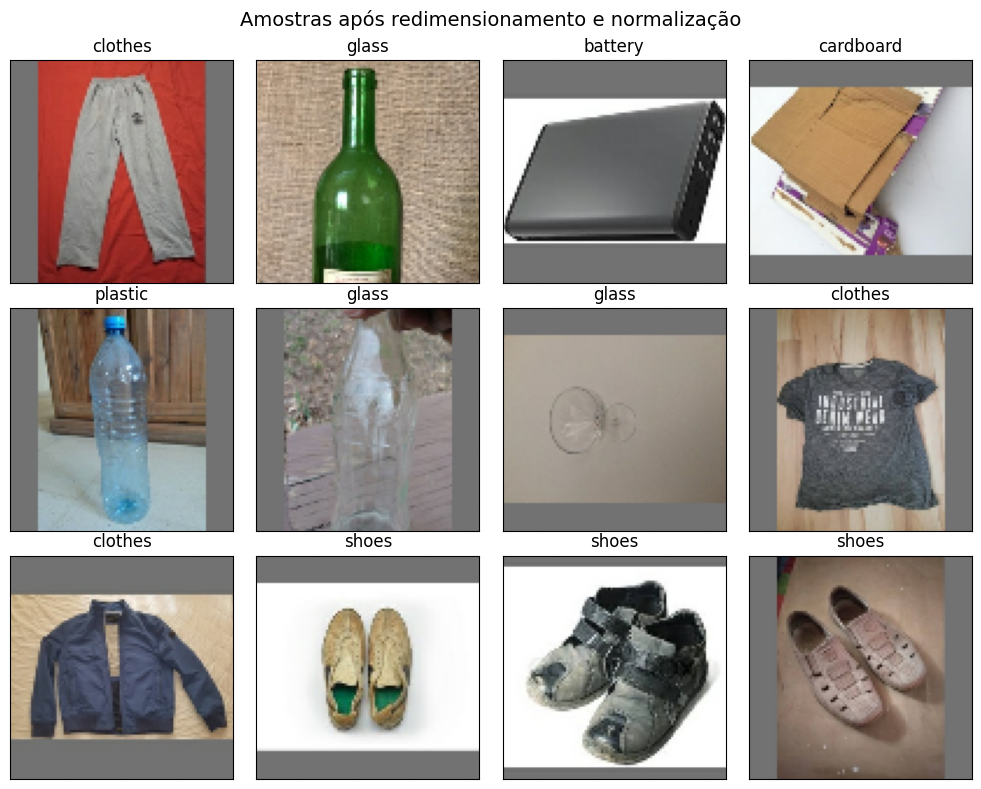

In [49]:
# --- Visualizando imagens após o pipeline de carregamento ---
plt.figure(figsize=(10, 8))
for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(imagens_batch[i])
        plt.title(class_names[int(labels_batch[i])])
        plt.xticks([]); plt.yticks([])
plt.suptitle("Amostras após redimensionamento e normalização", fontsize=14)
plt.tight_layout()
plt.show()


# 3. Construção da CNN Baseline

A CNN baseline contém os componentes mínimos exigidos:

- 2 camadas **convolucionais** (`Conv2D`) com ativação **ReLU**;
- camadas de **pooling** (`MaxPooling2D`);
- **regularização** com `Dropout`;
- 1 camada **densa** (`Dense`) na MLP;
- camada de **saída** com `softmax` para as 9 classes.

Hiperparâmetros definidos livremente (serão otimizados depois com Optuna).


In [50]:
# --- Função para criar a CNN baseline ---
def criar_cnn_baseline():
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

modelo_baseline = criar_cnn_baseline()
modelo_baseline.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,985,609 (15.20 MB)

 Trainable params: 3,985,609 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

### 📝 Analise — Arquitetura da baseline

**Pontos principais a destacar:**

- **Quase todos os parametros estao na 1a camada densa.** Sozinha, a `Dense(128)` concentra **3,96 milhoes** dos ~3,99 milhoes de pesos (cerca de **99,5%**). Isso acontece porque o `Flatten` gera **30.976** valores e cada um se conecta aos 128 neuronios (30.976 x 128 ≈ 3,96M). Ja as camadas **convolucionais** tem pouquissimos pesos (896 + 18.496 ≈ 19 mil), pois reaproveitam os mesmos filtros por toda a imagem.
- **Consequencia:** por ter tantos pesos concentrados na parte densa, a baseline tem **alta capacidade de memorizar** e tende ao **overfitting** — por isso a importancia do `Dropout` e do *early stopping*. Esse e justamente um dos pontos que o tuning com Optuna (e a `BatchNormalization`) busca melhorar.
- **Arquitetura proposital­mente simples:** 2 blocos convolucionais + 1 camada densa. Ela serve como **ponto de comparacao (baseline)** para medir o ganho da versao otimizada e do MobileNetV2.


## Treinamento da CNN baseline

Treinamos na amostra de tuning, com **early stopping** para interromper quando a validação parar de melhorar.


In [51]:
# --- Early stopping ---
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

EPOCHS_BASELINE = 15

history_baseline = modelo_baseline.fit(
    ds_treino_tuning,
    validation_data=ds_validacao_tuning,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.2080 - loss: 2.0929 - val_accuracy: 0.3880 - val_loss: 1.8091
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.4080 - loss: 1.6333 - val_accuracy: 0.4040 - val_loss: 1.6357
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.5407 - loss: 1.3192 - val_accuracy: 0.4780 - val_loss: 1.5507
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.6593 - loss: 1.0332 - val_accuracy: 0.4940 - val_loss: 1.4653
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.7467 - loss: 0.7861 - val_accuracy: 0.5040 - val_loss: 1.5258
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8340 - loss: 0.5502 - val_accuracy: 0.5040 - val_loss: 1.5834
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8840 - loss: 0.3779 - val_accuracy: 0.5300 - val_loss: 1.7731


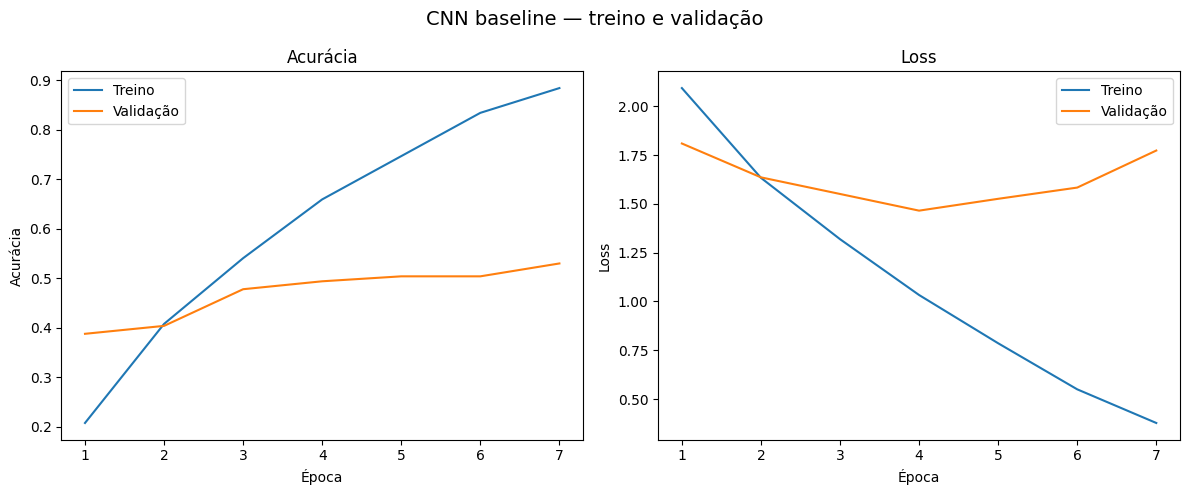

Melhor acurácia de validação da baseline: 0.5300
Menor loss de validação da baseline: 1.4653


In [52]:
# --- Função para plotar curvas de treino e validação ---
def plotar_curvas_treinamento(history, titulo="Curvas de treinamento"):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Treino")
    plt.plot(epochs_range, val_acc, label="Validação")
    plt.title("Acurácia"); plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Treino")
    plt.plot(epochs_range, val_loss, label="Validação")
    plt.title("Loss"); plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend()

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

plotar_curvas_treinamento(history_baseline, "CNN baseline — treino e validação")

melhor_val_acc_baseline = max(history_baseline.history["val_accuracy"])
melhor_val_loss_baseline = min(history_baseline.history["val_loss"])
print(f"Melhor acurácia de validação da baseline: {melhor_val_acc_baseline:.4f}")
print(f"Menor loss de validação da baseline: {melhor_val_loss_baseline:.4f}")


### 📝 Analise — Overfitting / Underfitting da baseline

As curvas de treino e validacao mostram um caso **claro de overfitting**.

**Evidencias nos graficos:**

- **Acuracia:** a de **treino** sobe continuamente ate ~0,88, enquanto a de **validacao** estaciona em torno de ~0,50 (melhor valor: **0,5300**). O *gap* entre as duas cresce ao longo das epocas — sinal tipico de que o modelo esta decorando o treino e nao generalizando.
- **Loss:** a de treino cai sem parar (~0,38), mas a de **validacao cai apenas ate a epoca 4 (~1,4653) e depois volta a subir** (~1,77). Esse "vale" seguido de subida e a assinatura do overfitting: a partir da epoca 4 o modelo passa a piorar nos dados que nao viu. Foi por isso que o *early stopping* (com `restore_best_weights=True`) restaurou os pesos da melhor epoca.

**Por que aconteceu:**

1. **Capacidade alta demais para pouco dado.** Como visto no `summary()`, ~99,5% dos pesos (≈3,96M) estao na primeira camada densa. Esse excesso de parametros da ao modelo "memoria" suficiente para **decorar** as imagens de treino em vez de aprender padroes gerais.
2. **Amostra de treino pequena.** O treino da baseline roda na amostra de tuning (~1.500 imagens ÷ 9 classes ≈ 167 por classe). Muitos parametros + poucos exemplos = forte tendencia a overfitting.
3. **Regularizacao fraca.** A baseline usa apenas `Dropout(0.3)`, sem `BatchNormalization` e sem *data augmentation* — pouco "freio" contra a memorizacao.
4. **Imagens com muita variacao** (fundo, iluminacao) e classes visualmente parecidas (`paper`x`cardboard`, `glass`x`plastic`) tornam a memorizacao mais facil do que a generalizacao.

**Conclusao:** o resultado e **esperado para uma baseline** — ela serve justamente para evidenciar o problema e servir de ponto de comparacao. As proximas etapas atacam essas causas: o **Optuna** ajusta dropout/learning rate/filtros (e a arquitetura do tuning ja inclui `BatchNormalization`), e o **MobileNetV2** (transfer learning) traz pesos pre-treinados que generalizam muito melhor com poucos dados. Possiveis melhorias adicionais: *data augmentation*, trocar `Flatten` por `GlobalAveragePooling2D` (reduz drasticamente os parametros) e treinar no conjunto completo em vez da amostra de tuning.

# 4. Ajuste de Hiperparâmetros com Optuna

Usamos o **Optuna** com o sampler **TPE** e orçamento fixo de **15 trials**. Cada trial testa uma combinação de hiperparâmetros (filtros, unidades densas, dropout e learning rate), com **early stopping**. O tuning roda na amostra estratificada menor.

Adicionamos `BatchNormalization` (camada de normalização) na arquitetura do tuning.


In [53]:
# --- CNN com hiperparâmetros sugeridos pelo Optuna ---
def criar_cnn_optuna(trial):
    num_filtros_1 = trial.suggest_int("num_filtros_1", 16, 64, step=16)
    num_filtros_2 = trial.suggest_int("num_filtros_2", 32, 128, step=32)
    dense_units   = trial.suggest_int("dense_units", 64, 256, step=64)
    dropout_rate  = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(num_filtros_1, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(num_filtros_2, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [54]:
# --- Função objetivo: cada trial = uma configuração de hiperparâmetros ---
def objective(trial):
    model = criar_cnn_optuna(trial)
    early_stopping_trial = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
    history = model.fit(
        ds_treino_tuning,
        validation_data=ds_validacao_tuning,
        epochs=10,
        callbacks=[early_stopping_trial],
        verbose=0
    )
    return max(history.history["val_accuracy"])


In [55]:
# --- Execução do Optuna com TPE (orçamento fixo de trials) ---
N_TRIALS = 15
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS)

print("Melhor trial:")
print(f"Número do trial: {study.best_trial.number}")
print(f"Acurácia de validação: {study.best_value:.4f}")
print("\nHiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"{param}: {value}")


[I 2026-06-07 23:14:08,779] A new study created in memory with name: no-name-125b113b-6fbb-47ef-8137-1667f94d3498
[I 2026-06-07 23:15:31,670] Trial 0 finished with value: 0.1940000057220459 and parameters: {'num_filtros_1': 32, 'num_filtros_2': 128, 'dense_units': 192, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0002051338263087451}. Best is trial 0 with value: 0.1940000057220459.
[I 2026-06-07 23:16:01,621] Trial 1 finished with value: 0.20399999618530273 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 32, 'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.0026070247583707684}. Best is trial 1 with value: 0.20399999618530273.
[I 2026-06-07 23:17:14,675] Trial 2 finished with value: 0.23800000548362732 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 128, 'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0002310201887845295}. Best is trial 2 with value: 0.23800000548362732.
[I 2026-06-07 23:17:55,686] Trial 3 finished with value: 0.2160000056

Melhor trial:
Número do trial: 10
Acurácia de validação: 0.3720

Hiperparâmetros encontrados:
num_filtros_1: 32
num_filtros_2: 128
dense_units: 256
dropout_rate: 0.1
learning_rate: 0.008383764830449055


# 5. Análise dos Trials e dos Resultados


In [56]:
# --- Tabela com os trials executados ---
df_trials = study.trials_dataframe()
colunas_interesse = [
    "number", "value",
    "params_num_filtros_1", "params_num_filtros_2",
    "params_dense_units", "params_dropout_rate",
    "params_learning_rate", "state"
]
df_trials_resumo = df_trials[colunas_interesse].copy().rename(columns={
    "number": "trial", "value": "val_accuracy",
    "params_num_filtros_1": "filtros_1", "params_num_filtros_2": "filtros_2",
    "params_dense_units": "dense_units", "params_dropout_rate": "dropout",
    "params_learning_rate": "learning_rate", "state": "status"
})
df_trials_resumo = df_trials_resumo.sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(df_trials_resumo)


,trial,val_accuracy,filtros_1,filtros_2,dense_units,dropout,learning_rate,status
0,10,0.372,32,128,256,0.1,0.008384,COMPLETE
1,14,0.266,32,96,256,0.1,0.003498,COMPLETE
2,11,0.242,32,128,256,0.1,0.009743,COMPLETE
3,2,0.238,16,128,256,0.2,0.000231,COMPLETE
4,8,0.232,16,64,64,0.5,0.000329,COMPLETE
5,3,0.216,16,64,192,0.3,0.000382,COMPLETE
6,1,0.204,16,32,256,0.4,0.002607,COMPLETE
7,7,0.198,64,64,64,0.4,0.000759,COMPLETE
8,6,0.198,48,32,64,0.5,0.008536,COMPLETE
9,0,0.194,32,128,192,0.3,0.000205,COMPLETE


,Modelo,Acurácia de validação
0,CNN baseline,0.530
1,CNN otimizada (Optuna),0.372


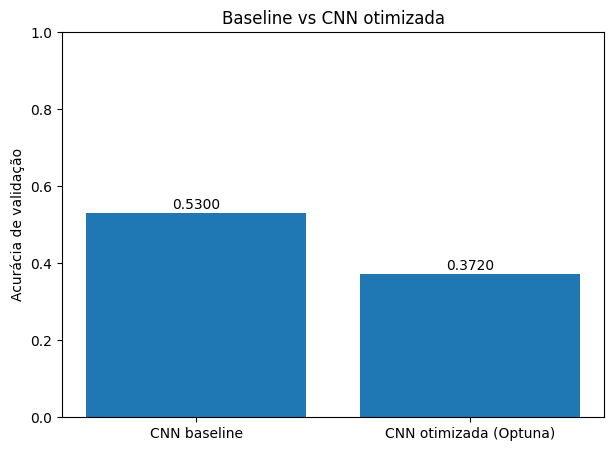

In [57]:
# --- Comparação: baseline vs melhor modelo do Optuna (na validação de tuning) ---
df_comparacao_validacao = pd.DataFrame({
    "Modelo": ["CNN baseline", "CNN otimizada (Optuna)"],
    "Acurácia de validação": [melhor_val_acc_baseline, study.best_value]
})
display(df_comparacao_validacao)

plt.figure(figsize=(7, 5))
plt.bar(df_comparacao_validacao["Modelo"], df_comparacao_validacao["Acurácia de validação"])
plt.ylim(0, 1)
plt.ylabel("Acurácia de validação")
plt.title("Baseline vs CNN otimizada")
for i, valor in enumerate(df_comparacao_validacao["Acurácia de validação"]):
    plt.text(i, valor + 0.01, f"{valor:.4f}", ha="center")
plt.show()


C:\Users\Felipe Cruz\AppData\Local\Temp\ipykernel_18020\3072079061.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


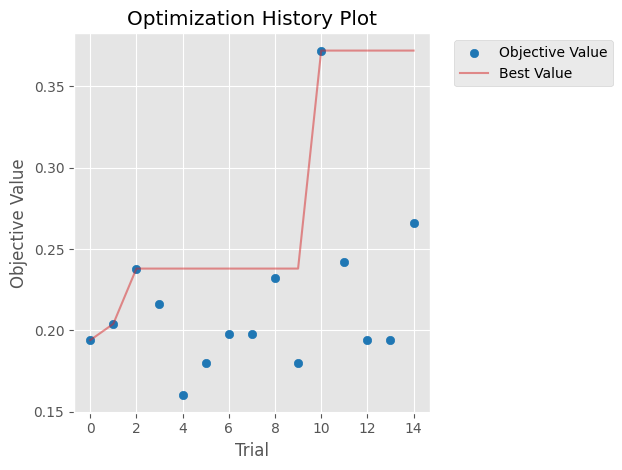

In [58]:
# Usamos o backend matplotlib do Optuna (nao depende de plotly).
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()


C:\Users\Felipe Cruz\AppData\Local\Temp\ipykernel_18020\2807713576.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


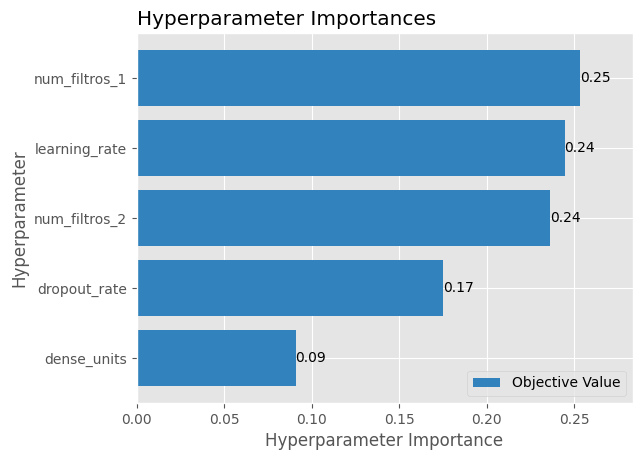

In [59]:
# Usamos o backend matplotlib do Optuna (nao depende de plotly).
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()


### 📝 Análise — Resultados do Optuna

> **O que interpretar aqui:**
> - O tuning **melhorou** em relação à baseline? Compare os dois valores de acurácia.
> - Qual foi a **melhor configuração** encontrada (filtros, dropout, learning rate)?
> - No gráfico de **importância**, quais hiperparâmetros pesaram mais (normalmente o *learning rate*)?
> - O melhor trial parece **consistente** (vários trials bons e parecidos) ou **isolado** (só um se destacou)?

_(escreva sua análise aqui)_


## Treinamento final do modelo vencedor

Treinamos a melhor configuração no **maior conjunto de treino viável** (treino completo da subamostra), mantendo o teste separado.


In [60]:
# --- Modelo vencedor com os melhores hiperparâmetros ---
best_params = study.best_params

def criar_cnn_com_params(params):
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(params["num_filtros_1"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(params["num_filtros_2"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(params["dense_units"], activation="relu"),
        keras.layers.Dropout(params["dropout_rate"]),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

modelo_vencedor = criar_cnn_com_params(best_params)
modelo_vencedor.summary()


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 45, 45, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │    15,859,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,900,809 (60.66 MB)

 Trainable params: 15,900,489 (60.66 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 448ms/step - accuracy: 0.2165 - loss: 44.1842 - val_accuracy: 0.1465 - val_loss: 2.1614
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 60s 452ms/step - accuracy: 0.2179 - loss: 2.0589 - val_accuracy: 0.1787 - val_loss: 2.0436
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 59s 446ms/step - accuracy: 0.2312 - loss: 2.0491 - val_accuracy: 0.2264 - val_loss: 2.0376


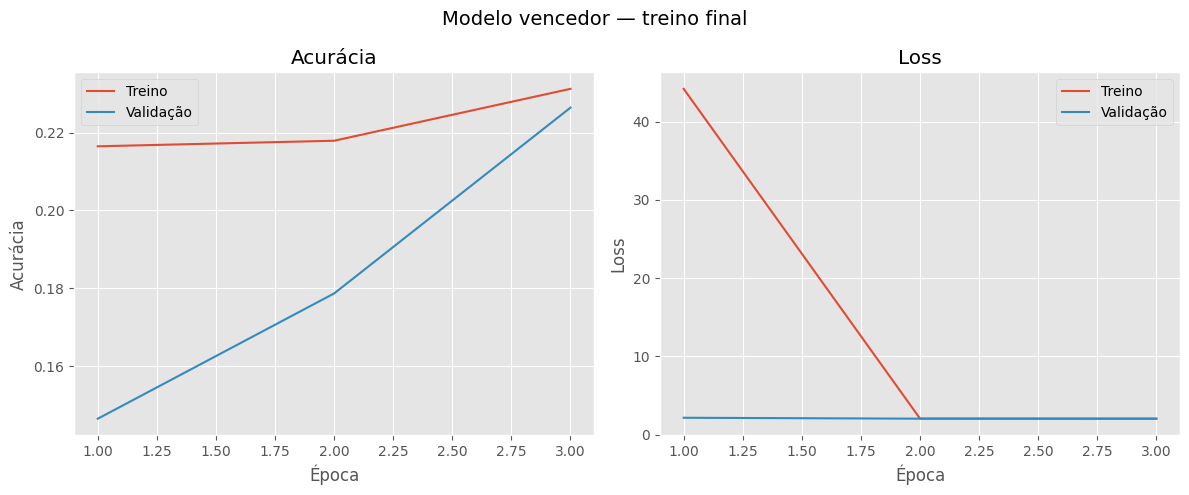

In [61]:
# --- Datasets completos para treino final e avaliação ---
ds_treino = criar_dataset(df_treino, shuffle=True)
ds_validacao = criar_dataset(df_validacao, shuffle=False)
ds_teste = criar_dataset(df_teste, shuffle=False)

EPOCHS_FINAL = 20
history_vencedor = modelo_vencedor.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=EPOCHS_FINAL,
    callbacks=[early_stopping],
    verbose=1
)
plotar_curvas_treinamento(history_vencedor, "Modelo vencedor — treino final")


## Avaliação final no conjunto de teste

O conjunto de teste é usado **apenas agora**. Calculamos acurácia, *loss*, relatório por classe (precisão, recall, F1) e a **matriz de confusão**.


In [62]:
# --- Avaliação no teste ---
test_loss, test_acc = modelo_vencedor.evaluate(ds_teste, verbose=1)
print(f"\nLoss no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.1467 - loss: 2.1615

Loss no teste: 2.1615
Acurácia no teste: 0.1467


In [63]:
# --- Coleta de rótulos verdadeiros e previstos no teste ---
def obter_y_true_y_pred(model, ds):
    y_true, y_pred = [], []
    for imagens, labels in ds:
        probs = model.predict(imagens, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = obter_y_true_y_pred(modelo_vencedor, ds_teste)

print("Relatório de classificação (CNN otimizada):\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Relatório de classificação (CNN otimizada):

              precision    recall  f1-score   support

     battery       0.00      0.00      0.00        58
  biological       0.00      0.00      0.00        53
   cardboard       0.00      0.00      0.00       108
     clothes       0.00      0.00      0.00       144
       glass       0.15      1.00      0.26       132
       metal       0.00      0.00      0.00        71
       paper       0.00      0.00      0.00       102
     plastic       0.00      0.00      0.00       122
       shoes       0.00      0.00      0.00       110

    accuracy                           0.15       900
   macro avg       0.02      0.11      0.03       900
weighted avg       0.02      0.15      0.04       900



c:\Users\Felipe Cruz\Desktop\CESUPA\7° SEMESTRE\MACHINE LEARNING E OTIMIZACAO\26.05.09_RedesNeuraisConvolucionais\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Felipe Cruz\Desktop\CESUPA\7° SEMESTRE\MACHINE LEARNING E OTIMIZACAO\26.05.09_RedesNeuraisConvolucionais\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Felipe Cruz\Desktop\CESUPA\7° SEMESTRE\MACHINE LEARNING E OTIMIZACAO\26.05.09_RedesNeuraisConvolucionais\.venv\Lib\site-packages\sklearn\metrics\_classif

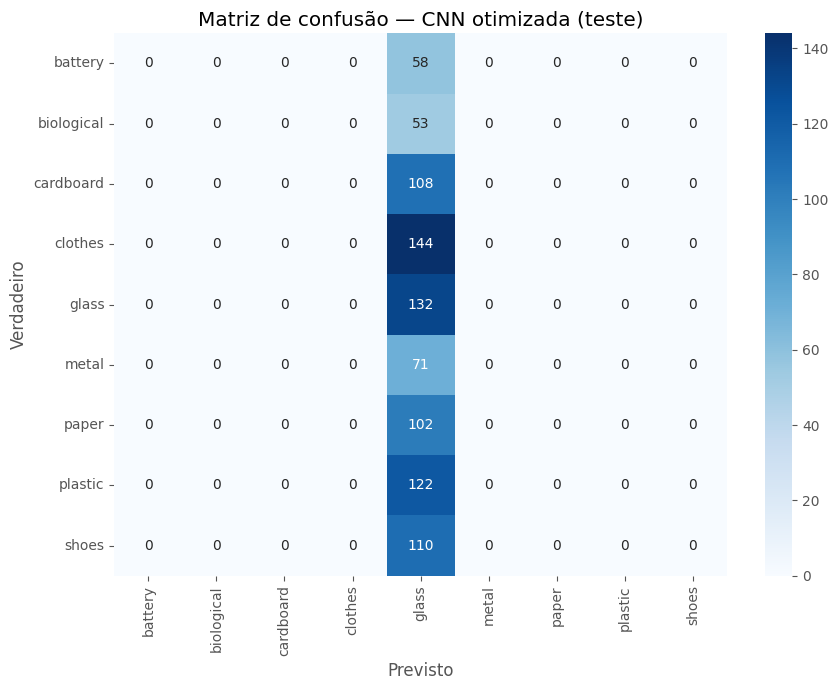

In [64]:
# --- Matriz de confusão ---
def plotar_matriz_confusao(y_true, y_pred, titulo="Matriz de confusão"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Previsto"); plt.ylabel("Verdadeiro")
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

plotar_matriz_confusao(y_true, y_pred, "Matriz de confusão — CNN otimizada (teste)")


### 📝 Análise — Avaliação final da CNN otimizada

> **O que interpretar aqui:**
> - A acurácia no **teste** foi compatível com a da **validação**? (Diferença grande sugere overfitting.)
> - Pela matriz de confusão, **quais classes foram mais confundidas** entre si? (ex.: `paper` × `cardboard`, `glass` × `plastic`). Tente explicar o porquê (aparência parecida).
> - Olhando o relatório, quais classes tiveram **menor F1** (provavelmente as com menos imagens)?
> - Quais **limitações** o experimento teve (subamostra, poucas épocas, poucos trials, desbalanceamento)?

_(escreva sua análise aqui)_



In [65]:
# --- Tabela final de comparação ---
df_resultado_final = pd.DataFrame({
    "Modelo/Etapa": [
        "CNN baseline - validação tuning",
        "Melhor Optuna - validação tuning",
        "CNN otimizada - teste final"
    ],
    "Acurácia": [melhor_val_acc_baseline, study.best_value, test_acc]
})
display(df_resultado_final)


,Modelo/Etapa,Acurácia
0,CNN baseline - validação tuning,0.530000
1,Melhor Optuna - validação tuning,0.372000
2,CNN otimizada - teste final,0.146667


# 6. Arquitetura Clássica da Literatura — MobileNetV2 (Transfer Learning)

**Arquitetura escolhida:** **MobileNetV2** — Sandler et al., **2018** (Google).

**Diferencial:** foi projetada para ser **leve e eficiente** (ideal para dispositivos móveis). Suas principais inovações são as **depthwise separable convolutions** (separam o filtro espacial do filtro entre canais, reduzindo muito o número de operações) e os **inverted residuals com linear bottlenecks** (blocos residuais que expandem e depois comprimem os canais, preservando informação com poucos parâmetros).

> 🖼️ **Insira aqui** um diagrama/imagem da arquitetura do MobileNetV2 (slide/relatório).

### Transfer Learning — o que foi feito
Usamos os **pesos pré-treinados no ImageNet** e **congelamos** a base convolucional (não treinamos esses pesos). Por cima, adicionamos um classificador novo (`GlobalAveragePooling` + `Dense` de saída) treinado nas nossas 9 classes. Como o `MobileNetV2` espera pixels em **[-1, 1]**, convertemos as imagens (que estão em [0, 1]) com uma camada `Rescaling`.



In [66]:
# --- Modelo com Transfer Learning (MobileNetV2 pré-treinado no ImageNet) ---
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,        # remove o classificador original (1000 classes ImageNet)
    weights="imagenet"
)
base_model.trainable = False  # congela a base (não treina os pesos pré-treinados)

modelo_transfer = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    keras.layers.Rescaling(2.0, offset=-1.0),   # de [0,1] para [-1,1] (esperado pelo MobileNetV2)
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_classes, activation="softmax")
])

modelo_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
modelo_transfer.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.6280 - loss: 1.1123 - val_accuracy: 0.8380 - val_loss: 0.5115
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.8261 - loss: 0.5240 - val_accuracy: 0.8524 - val_loss: 0.4250
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.8554 - loss: 0.4178 - val_accuracy: 0.8724 - val_loss: 0.3929
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.8864 - loss: 0.3451 - val_accuracy: 0.8824 - val_loss: 0.3841
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - accuracy: 0.8969 - loss: 0.2984 - val_accuracy: 0.8757 - val_loss: 0.3765
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - accuracy: 0.9078 - loss: 0.2620 - val_accuracy: 0.8790 - val_loss: 0.3907
Epoch 7/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.9178 - loss: 0.2489 - val_accuracy: 0.8835 - val_loss: 0.3658
Epoch 8/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.9228 - loss: 0

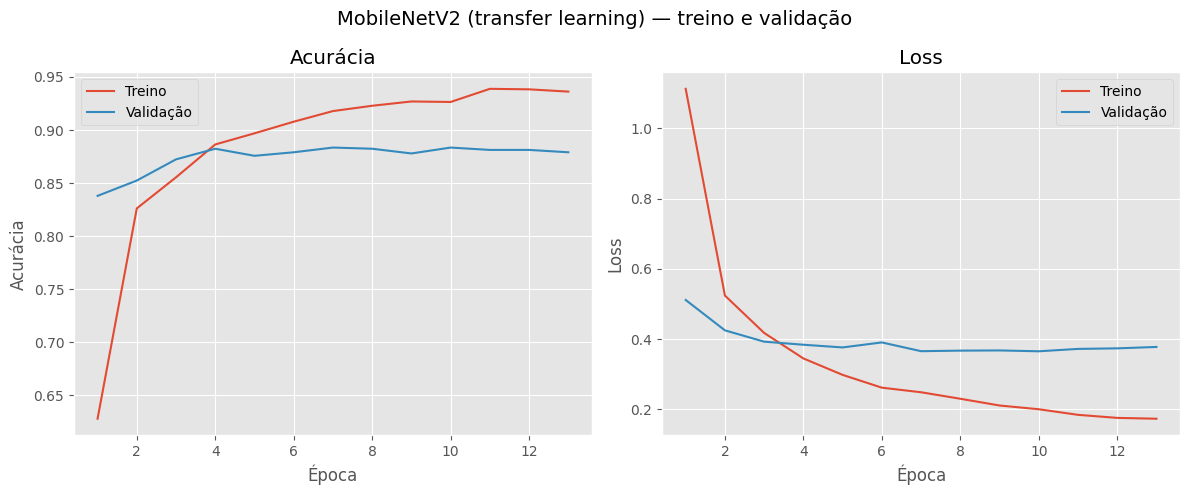

In [67]:
# --- Treinamento do modelo de transfer learning ---
EPOCHS_TRANSFER = 15
history_transfer = modelo_transfer.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=EPOCHS_TRANSFER,
    callbacks=[early_stopping],
    verbose=1
)
plotar_curvas_treinamento(history_transfer, "MobileNetV2 (transfer learning) — treino e validação")


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.8589 - loss: 0.4096

Loss no teste (MobileNetV2): 0.4096
Acurácia no teste (MobileNetV2): 0.8589

              precision    recall  f1-score   support

     battery       0.96      0.84      0.90        58
  biological       0.96      0.96      0.96        53
   cardboard       0.88      0.81      0.84       108
     clothes       0.97      0.95      0.96       144
       glass       0.80      0.86      0.83       132
       metal       0.79      0.70      0.75        71
       paper       0.71      0.83      0.77       102
     plastic       0.80      0.78      0.79       122
       shoes       0.94      0.95      0.95       110

    accuracy                           0.86       900
   macro avg       0.87      0.86      0.86       900
weighted avg       0.86      0.86      0.86       900



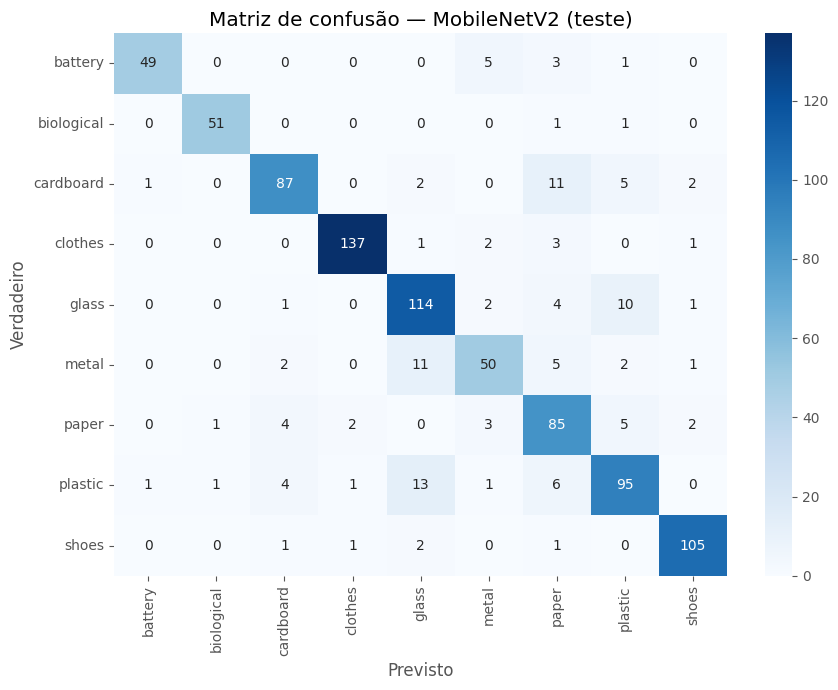

In [68]:
# --- Avaliação no teste e matriz de confusão (MobileNetV2) ---
test_loss_tl, test_acc_tl = modelo_transfer.evaluate(ds_teste, verbose=1)
print(f"\nLoss no teste (MobileNetV2): {test_loss_tl:.4f}")
print(f"Acurácia no teste (MobileNetV2): {test_acc_tl:.4f}\n")

y_true_tl, y_pred_tl = obter_y_true_y_pred(modelo_transfer, ds_teste)
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))
plotar_matriz_confusao(y_true_tl, y_pred_tl, "Matriz de confusão — MobileNetV2 (teste)")


,Modelo,Acurácia no teste
0,CNN otimizada (Optuna),0.146667
1,MobileNetV2 (Transfer Learning),0.858889


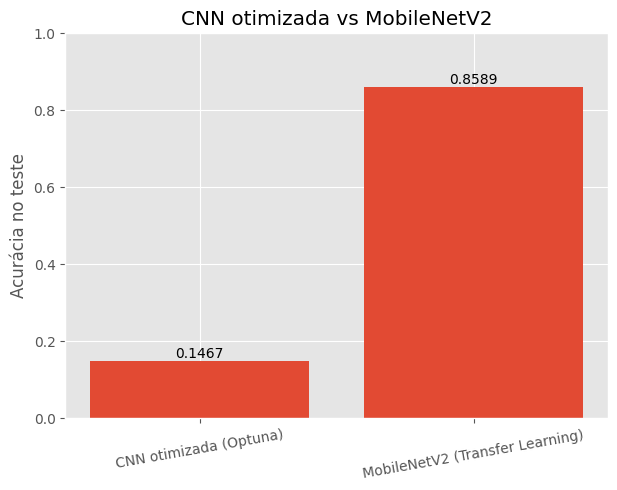

In [69]:
# --- Comparação final: baseline vs CNN otimizada vs MobileNetV2 (no teste) ---
df_comparacao_final = pd.DataFrame({
    "Modelo": ["CNN otimizada (Optuna)", "MobileNetV2 (Transfer Learning)"],
    "Acurácia no teste": [test_acc, test_acc_tl]
})
display(df_comparacao_final)

plt.figure(figsize=(7, 5))
plt.bar(df_comparacao_final["Modelo"], df_comparacao_final["Acurácia no teste"])
plt.ylim(0, 1)
plt.ylabel("Acurácia no teste")
plt.title("CNN otimizada vs MobileNetV2")
for i, valor in enumerate(df_comparacao_final["Acurácia no teste"]):
    plt.text(i, valor + 0.01, f"{valor:.4f}", ha="center")
plt.xticks(rotation=10)
plt.show()


### 📝 Análise — Arquitetura clássica vs CNN própria

> **O que interpretar aqui:**
> - O **MobileNetV2** (transfer learning) superou a sua CNN otimizada? Em quanto?
> - Por que o transfer learning costuma ir melhor mesmo com poucos dados? (os pesos do ImageNet já aprenderam a detectar bordas, texturas e formas).
> - Houve sinais de overfitting nas curvas do MobileNetV2?
> - Deixe claro novamente que foi usado **transfer learning com base congelada** (não treino do zero).

_(escreva sua análise aqui)_


# Conclusão

> **O que escrever aqui:** um resumo geral do trabalho — qual modelo teve o melhor desempenho, o que o tuning trouxe de ganho, as principais dificuldades (desbalanceamento, custo computacional, classes parecidas) e possíveis melhorias futuras (mais dados, *data augmentation*, *fine-tuning* das últimas camadas do MobileNetV2, mais trials no Optuna).

_(escreva sua conclusão aqui)_
